In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from flowpde.datasets.exponax import BurgersGenerator, BurgersConfig
from flowpde.models.unet import UNet
from flowpde.datasets.normalization import FieldNormalizer
from flowpde.flows import NeuralODEFlow
from flowpde.objectives import FlowMatchingObjective
from flowpde.trainers.evaluation import FlowEvaluator
from flowpde.trainers import Trainer

## Step 1

In [2]:
cfg = BurgersConfig()
generator = BurgersGenerator(cfg)
train_data = generator.generate(num_samples = 1000, seed=0, problem='forward')
val_data = generator.generate(num_samples=50, seed=1, problem='forward')

Generated Burgers 1D dataset: 1000 samples, 64 grid, 400 steps (dt=0.001), nu ~ LogUniform(1e-02, 1e-02)
Generated Burgers 1D dataset: 50 samples, 64 grid, 400 steps (dt=0.001), nu ~ LogUniform(1e-02, 1e-02)


In [3]:
def visualize_burgers_dataset(dataset, n=6, title=None):
    """
    Visualize Burgers initial conditions and final states.

    Works for FlowPDE Burgers datasets with:
        dataset.data['initial']
        dataset.data['final']
    """

    initial = dataset.data["initial"]  # (N, C, X) for 1D
    final = dataset.data["final"]

    n = min(n, len(initial))
    spatial_dim = initial.ndim - 2

    fig, axes = plt.subplots(
        2, n,
        figsize=(2.8 * n, 5.0),
        constrained_layout=True,
        squeeze=False,
    )

    if spatial_dim == 1:
        x = np.linspace(0, 1, initial.shape[-1], endpoint=False)

        for j in range(n):
            u0 = initial[j].squeeze().cpu().numpy()
            uT = final[j].squeeze().cpu().numpy()

            for row, (field, name, color) in enumerate(
                [(u0, "initial $u(x,0)$", "tab:blue"),
                 (uT, "final $u(x,T)$", "tab:red")]
            ):
                ax = axes[row, j]
                ax.plot(x, field, color=color, linewidth=2)
                ax.grid(alpha=0.25)

                if j == 0:
                    ax.set_ylabel(name, fontsize=11)

                if row == 0:
                    ax.set_title(f"sample {j}", fontsize=9)

                ax.set_xlabel("$x$")

    elif spatial_dim == 2:
        for j in range(n):
            u0 = initial[j].squeeze().cpu().numpy()
            uT = final[j].squeeze().cpu().numpy()

            vmax = max(abs(u0).max(), abs(uT).max())

            for row, (field, name) in enumerate(
                [(u0, "initial $u(x,y,0)$"),
                 (uT, "final $u(x,y,T)$")]
            ):
                ax = axes[row, j]
                im = ax.imshow(
                    field,
                    cmap="RdBu_r",
                    origin="lower",
                    vmin=-vmax,
                    vmax=vmax,
                )
                ax.set_xticks([])
                ax.set_yticks([])

                if j == 0:
                    ax.set_ylabel(name, fontsize=11)

                if row == 0:
                    ax.set_title(f"sample {j}", fontsize=9)

                fig.colorbar(im, ax=ax, fraction=0.046, shrink=0.9)

    else:
        raise ValueError(f"Only 1D and 2D Burgers visualization supported, got {spatial_dim}D")

    if title is None:
        title = "Burgers equation: initial conditions and final states"

    fig.suptitle(title, fontsize=13)
    plt.show()

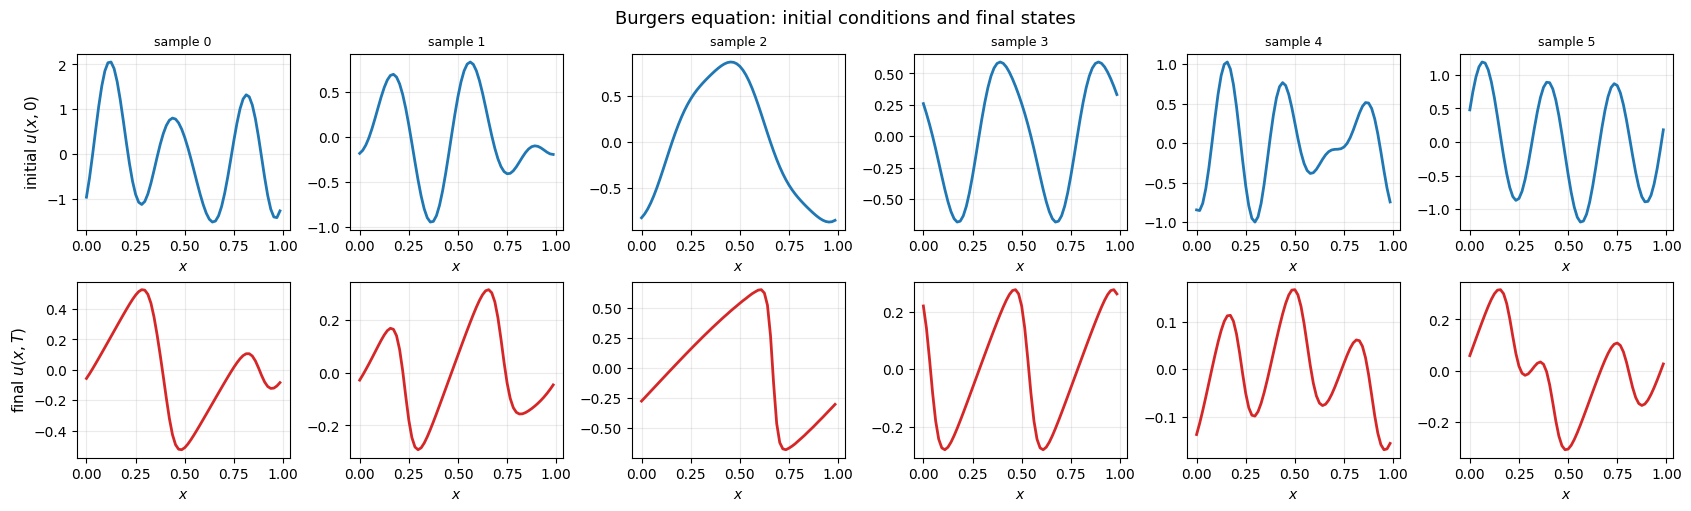

In [4]:
visualize_burgers_dataset(train_data, n=6)

In [5]:
normalizer = FieldNormalizer.from_dataset(train_data)
train_data.set_normalizer(normalizer)
val_data.set_normalizer(normalizer)

In [6]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64)
sample = train_data[0]
cond_ch = sample['input'].shape[0]      # +1 if obs masking is on
targ_ch = sample['target'].shape[0]
cond_ch, targ_ch

(1, 1)

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model = UNet(spatial_dim = 1,
            spatial_size = 64,
            base_channels = 16,
            solution_channels = targ_ch,
            condition_channels = cond_ch,
            use_attention = False).to(device)

Using device: cuda


In [8]:
flow = NeuralODEFlow(model, 
                target_key = 'target', 
                condition_key = 'input')
flow = flow.to(device).float()
objective = FlowMatchingObjective(flow,
                                path = 'linear',
                                time_sampler = 'uniform')
optimizer = torch.optim.Adam(objective.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

In [9]:
evaluator = FlowEvaluator(objective, 
                          val_loader,
                          target_key='target',
                          condition_key='input',
                          n_steps = 50,
                          solver='euler',
                          normalizer=normalizer,
                          target_fields=val_data.target_fields,
                          metrics=['rel_l2'],
                          max_batches=4,)

In [10]:
trainer = Trainer(objective,
                  optimizer,
                  scheduler,
                  device)

In [11]:
trainer.train(train_loader,
             epochs = 1000,
             print_stats_interval = 10,
             save_dir='../runs/burger1d_fm',
             save_interval=25)

Epoch: 0001/1000 | Train_Loss: 1.935873 | LR: 1.00e-03 | Time: 0.738707
Epoch: 0011/1000 | Train_Loss: 0.337673 | LR: 9.93e-04 | Time: 0.164398
Epoch: 0021/1000 | Train_Loss: 0.217832 | LR: 9.73e-04 | Time: 0.180525
Epoch: 0031/1000 | Train_Loss: 0.171445 | LR: 9.42e-04 | Time: 0.176698
Epoch: 0041/1000 | Train_Loss: 0.161177 | LR: 9.00e-04 | Time: 0.174581
Epoch: 0051/1000 | Train_Loss: 0.134934 | LR: 8.48e-04 | Time: 0.164382
Epoch: 0061/1000 | Train_Loss: 0.126774 | LR: 7.88e-04 | Time: 0.157582
Epoch: 0071/1000 | Train_Loss: 0.132344 | LR: 7.20e-04 | Time: 0.195247
Epoch: 0081/1000 | Train_Loss: 0.121454 | LR: 6.47e-04 | Time: 0.180171
Epoch: 0091/1000 | Train_Loss: 0.111457 | LR: 5.70e-04 | Time: 0.165415
Epoch: 0101/1000 | Train_Loss: 0.104871 | LR: 4.92e-04 | Time: 0.344314
Epoch: 0111/1000 | Train_Loss: 0.100405 | LR: 4.14e-04 | Time: 0.213472
Epoch: 0121/1000 | Train_Loss: 0.100221 | LR: 3.38e-04 | Time: 0.181338
Epoch: 0131/1000 | Train_Loss: 0.096784 | LR: 2.66e-04 | Time: 0

In [12]:
batch = next(iter(val_loader))

condition = batch["input"].to(device)   # normalized initial u(x,0)
target = batch["target"].to(device)     # normalized true final u(x,T)

with torch.no_grad():
    x_init = torch.randn_like(target)

    pred = objective.sample(
        condition=condition,
        n_steps=100,
        solver="euler",
        x_init=x_init,
    )

    pred = pred.reshape_as(target)

In [13]:
pred_real = normalizer.denormalize_channels(
    val_data.target_fields,
    pred.cpu()
)

target_real = normalizer.denormalize_channels(
    val_data.target_fields,
    target.cpu()
)

input_real = normalizer.denormalize_channels(
    val_data.input_fields,
    condition.cpu()
)

In [14]:
rel_l2 = (
    torch.linalg.vector_norm((pred_real - target_real).flatten(1), dim=1)
    / torch.linalg.vector_norm(target_real.flatten(1), dim=1).clamp_min(1e-8)
)

print("Mean relative L2:", rel_l2.mean().item())

Mean relative L2: 0.2998241186141968


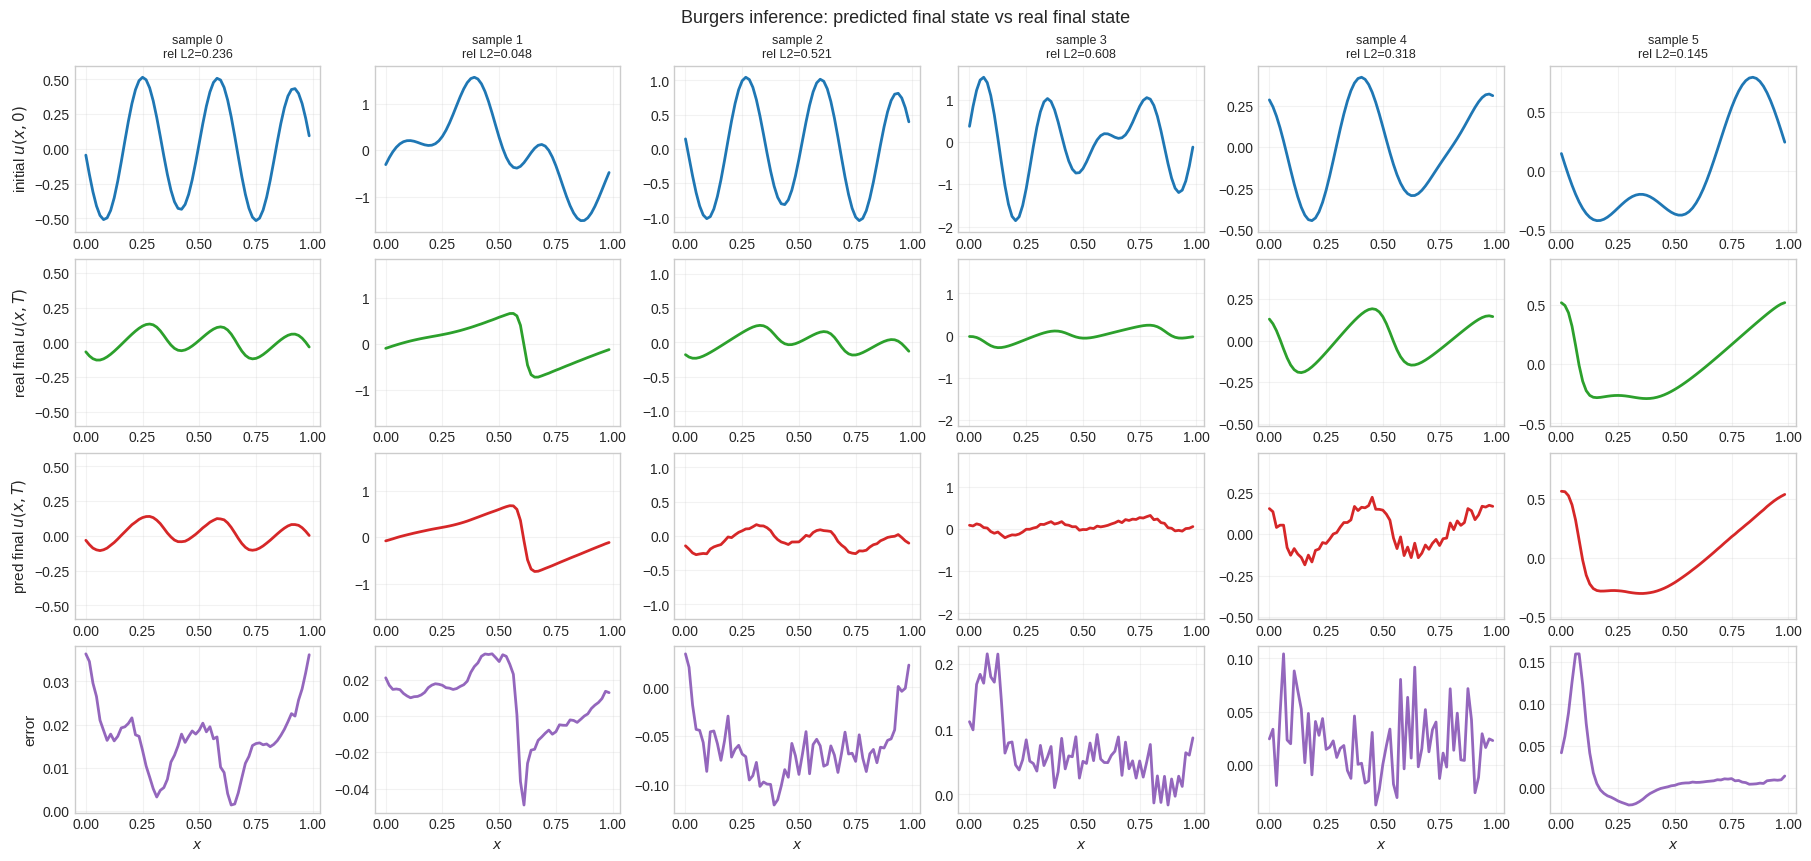

In [15]:
n = 6
x = np.linspace(0, 1, input_real.shape[-1], endpoint=False)

fig, axes = plt.subplots(
    4, n,
    figsize=(3.0 * n, 8.5),
    constrained_layout=True,
    squeeze=False,
)

for j in range(n):
    u0 = input_real[j, 0].numpy()
    u_true = target_real[j, 0].numpy()
    u_pred = pred_real[j, 0].numpy()
    err = u_pred - u_true

    y_min = min(u0.min(), u_true.min(), u_pred.min())
    y_max = max(u0.max(), u_true.max(), u_pred.max())
    pad = 0.08 * (y_max - y_min + 1e-8)

    rows = [
        (u0, "initial $u(x,0)$", "tab:blue"),
        (u_true, "real final $u(x,T)$", "tab:green"),
        (u_pred, "pred final $u(x,T)$", "tab:red"),
        (err, "error", "tab:purple"),
    ]

    for i, (field, label, color) in enumerate(rows):
        ax = axes[i, j]
        ax.plot(x, field, color=color, linewidth=2)
        ax.grid(alpha=0.25)

        if i < 3:
            ax.set_ylim(y_min - pad, y_max + pad)

        if j == 0:
            ax.set_ylabel(label, fontsize=11)

        if i == 0:
            ax.set_title(f"sample {j}\nrel L2={rel_l2[j]:.3f}", fontsize=9)

        if i == 3:
            ax.set_xlabel("$x$")

fig.suptitle("Burgers inference: predicted final state vs real final state", fontsize=13)
plt.show()